# Set Up

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import wandb
from PIL import Image

# Configuration

In [2]:
# Paths to dataset folders
TRAIN_DIR = "./data/train"
TEST_DIR = "./data/validate"

# Hyperparameters
NUM_CLASSES = 10
IMG_SIZE = 128  # Height and Width
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

# Use GPU if available, otherwise fall back to CPU
DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [3]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/oquinn/.netrc.
wandb: Currently logged in as: orlaith-quinn (orlaith-quinn-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# Initialise Weights and Biases
wandb.init(
    project="cnn-3layer",  # name of project on the W&B dashboard
    # name=run1,
    config={  # log hyperparameters automatically
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "num_classes": NUM_CLASSES,
        "img_size": IMG_SIZE,
        "optimizer": "Adam",
        "loss": "CrossEntropyLoss",
    },
)

# Load Data & Preprocess

In [5]:
# Training transforms: resize, convert to tensor, normalise (are we normalising??)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),          # Resize every image to 128x128
    transforms.ToTensor(),                            # Convert to tensor
    transforms.Normalize(                             # Normalise with mean and std of images across dataset
        mean=[0.4966, 0.4792, 0.3941],
        std =[0.2579, 0.2524, 0.2645]
    ),
])

# Test transforms: only resize, normalise?
test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.2579, 0.2524, 0.2645],
        std =[0.2579, 0.2524, 0.2645]
    ),
])

# Assign integer labels from subfolder names
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(root=TEST_DIR,  transform=test_transforms)

# Batch the data and shuffle training samples each epoch
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# CHECK: Print class names
class_names = train_dataset.classes
print(f"Classes: {class_names}")

Classes: ['cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'rabbit', 'sheep', 'squirrel', 'zebra']


# CNN Model

In [6]:
class CNN(nn.Module):
    """
    A 3-layer Convolutional Neural Network.

    Architecture:
        Conv Layer 1 → BatchNorm → ReLU → MaxPool
        Conv Layer 2 → BatchNorm → ReLU → MaxPool (Not sure if we decided on doing this or not?)
        Conv Layer 3 → BatchNorm → ReLU → MaxPool
        Flatten → Fully Connected → Dropout → Output (10 classes)
    """

    def __init__(self, num_classes: int = 10):
        super(CNN, self).__init__()

        # Convolutional block 1
        # Input:  (batch, 3, 128, 128)  — 3 RGB channels
        # Output: (batch, 32, 64, 64)   — after conv + 2x2 max-pool
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32,
                      kernel_size=3, padding=1),   
            nn.BatchNorm2d(32),                    
            nn.ReLU(inplace=True),                 
            nn.MaxPool2d(kernel_size=2, stride=2), 
        )

        # Convolutional block 2 
        # Input:  (batch, 32, 64, 64)
        # Output: (batch, 64, 32, 32)
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 64→32
        )

        # Convolutional block 3
        # Input:  (batch, 64, 32, 32)
        # Output: (batch, 128, 16, 16)
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128,
                      kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32→16
        )

        # Fully connected classifier
        # Flattened feature vector: 128 channels × 16 × 16 = 32768
        self.classifier = nn.Sequential(
            nn.Flatten(),                          # (batch, 128, 16, 16) → (batch, 32768)
            nn.Linear(128 * 16 * 16, 512),         # Fully connected layer
            nn.ReLU(inplace=True),
            # nn.Dropout(p=0.5),                     # Think I should leave this out for now and use it later in the regularisation?
            nn.Linear(512, num_classes),           # Output one logit per class
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass: run input through conv blocks then classifier."""
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.classifier(x)
        return x  # Raw logits — CrossEntropyLoss handles softmax internally


In [7]:
# Create instance of the model and move it to the selected device
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model)

CNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-

In [8]:
# CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Adam Optimiser
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training & Evaluation

Note: manually tracking loss and accuracy here, will incorporate weights and biases later.

In [9]:
def train(model, train_loader, criterion, optimizer, device):
    """
    Run one full epoch over the training set.

    Returns:
        avg_loss (float): mean loss across all batches
        accuracy (float): fraction of correctly classified samples
    """
    model.train()  # Enable training mode (dropout and batch-norm)

    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to the same device as model
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()             # Clear gradients from the previous step
        logits = model(images)            # Get raw class scores
        loss = criterion(logits, labels)  # Compute loss

        # Backward pass
        loss.backward()                # Compute gradients via backprop
        optimizer.step()               # Update weights

        # Metrics accumulation
        running_loss += loss.item() * images.size(0)   # Weighted by batch size
        preds = logits.argmax(dim=1)                   # Predicted class indices
        correct_preds += (preds == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = running_loss  / total_samples
    accuracy = correct_preds / total_samples
    return avg_loss, accuracy

In [10]:
def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on any DataLoader (validation or test).

    Returns:
        avg_loss  (float): mean loss
        accuracy  (float): fraction correct
        all_preds (list):  predicted class indices for each sample
        all_labels(list):  true class indices for each sample
    """
    model.eval()  # Enable evaluation mode (Disable dropout)

    running_loss = 0.0
    correct_preds = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No gradients needed — saves memory and time
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            correct_preds += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_preds .extend(preds .cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss  / total_samples
    accuracy = correct_preds / total_samples
    return avg_loss, accuracy, all_preds, all_labels

In [11]:
# Lists to store per-epoch metrics for plotting later
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

print("\n" + "=" * 55)
print(
    f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8}"
)
print("=" * 55)

for epoch in range(1, NUM_EPOCHS + 1):

    # One full pass over the training data
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, DEVICE)

    # Evaluate on test set at the end of every epoch
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, DEVICE)

    wandb.log(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
        }
    )

    # Record metrics
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>9.4f} | {test_loss:>9.4f} | {test_acc:>8.4f}"
    )


 Epoch | Train Loss | Train Acc | Test Loss | Test Acc
     1 |     2.0355 |    0.3630 |    1.9838 |   0.3070
     2 |     1.4908 |    0.4787 |    1.7168 |   0.4040
     3 |     1.3189 |    0.5423 |    1.7464 |   0.4120
     4 |     1.1781 |    0.5908 |    1.6603 |   0.4402
     5 |     1.0438 |    0.6359 |    1.5548 |   0.4623
     6 |     0.9074 |    0.6855 |    1.4842 |   0.4938
     7 |     0.7799 |    0.7277 |    1.8896 |   0.4440
     8 |     0.6555 |    0.7710 |    1.4306 |   0.5403
     9 |     0.5450 |    0.8091 |    1.5263 |   0.5312
    10 |     0.4274 |    0.8516 |    1.9662 |   0.4867


In [12]:
wandb.finish()

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▄▄▅▆▇▅██▆
test_loss,█▅▅▄▃▂▇▁▂█
train_accuracy,▁▃▄▄▅▆▆▇▇█
train_loss,█▆▅▄▄▃▃▂▂▁
epoch,10
test_accuracy,0.48667
test_loss,1.9662
train_accuracy,0.85162
train_loss,0.42744


# Results

In [13]:
# Final evaluation on test set
_, test_acc_final, all_preds, all_labels = evaluate(model, test_loader, criterion, DEVICE)
print(f"\nFinal test accuracy: {test_acc_final:.4f} ({test_acc_final*100:.2f}%)")


Final test accuracy: 0.4867 (48.67%)


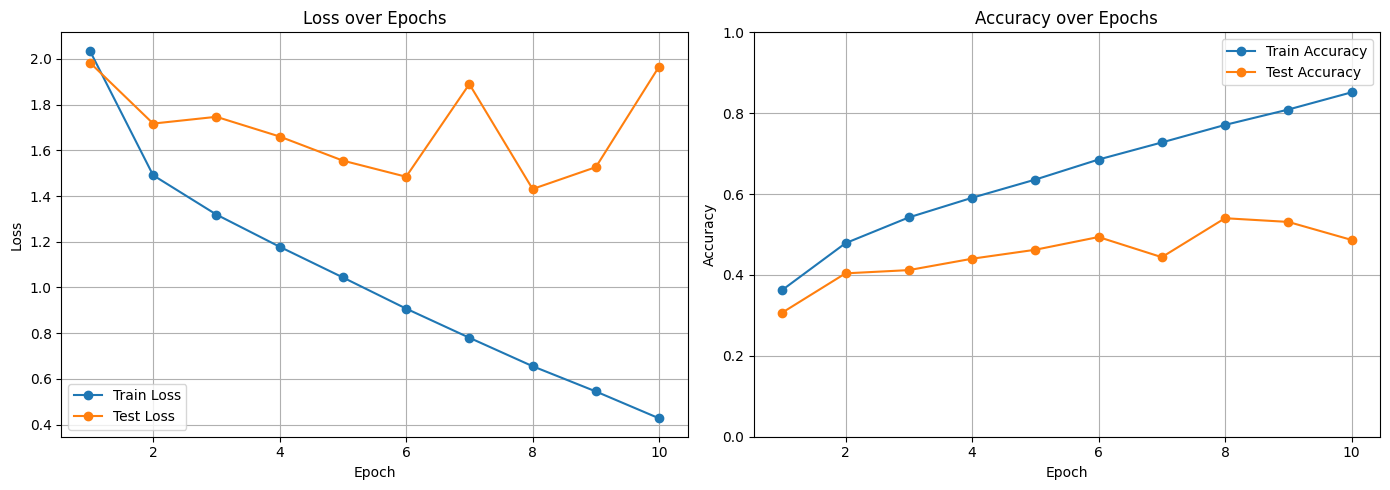

In [14]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
ax1.plot(epochs_range, history["test_loss"],  label="Test Loss",  marker="o")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy curve 
ax2.plot(epochs_range, history["train_acc"], label="Train Accuracy", marker="o")
ax2.plot(epochs_range, history["test_acc"],  label="Test Accuracy",  marker="o")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Per-class precision, recall, F1 score
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

         cat       0.49      0.40      0.44       600
     chicken       0.72      0.64      0.67       600
         cow       0.42      0.48      0.45       600
         dog       0.29      0.36      0.32       600
    elephant       0.74      0.27      0.40       600
       horse       0.75      0.29      0.42       600
      rabbit       0.53      0.48      0.51       600
       sheep       0.30      0.78      0.43       600
    squirrel       0.45      0.33      0.38       600
       zebra       0.96      0.83      0.89       600

    accuracy                           0.49      6000
   macro avg       0.56      0.49      0.49      6000
weighted avg       0.56      0.49      0.49      6000



In [32]:
# Confusion Matrix
def plot_cm(y_test, y_pred, class_names, version):
    cm = confusion_matrix(y_test, y_pred)
    display = ConfusionMatrixDisplay(cm, display_labels=class_names)

    display.plot(cmap=plt.cm.Blues, xticks_rotation=45)
    display.figure_.savefig(f'plots/cnn_3layer_cm_ver{version}.png', bbox_inches='tight')

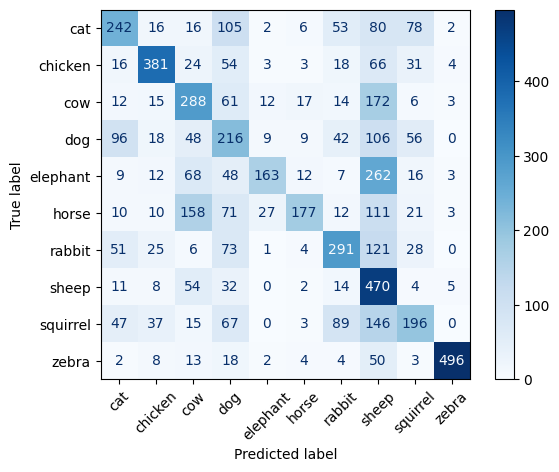

In [33]:
plot_cm(all_labels, all_preds, class_names, 1)

In [ ]:
# This saves it as a seperate run, I need to work on logging it to the same run
with wandb.init(project="cnn-3layer") as run:
    run.log({"Confusion Matrix": wandb.Image("./plots/cnn_3layer_cm_ver1.png")})

wandb: ERROR The nbformat package was not found. It is required to save notebook history.
